<a href="https://colab.research.google.com/github/NirmaliePerera/Big-Data-Analysis-Project-1/blob/main/BDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Big Data Analysis - Project**


---
**Goal:**
Explore the relationship between public debt and economic indicators such as GDP per capita and unemployment rate, as well as to analyze health indicators such as life expectancy and infant mortality rate in relation to internet usage.

A dataset of 160 countries with 40 characteristics such as debt, electricity consumption, and Internet users are taken for this analysis.

Why this analysis important?
* National - formulating better economic strategies, improve public health outcomes
* Organizational - decisions on global investments, healthcare strategies, or market opportunities.
* Global Context - help UN or the World Bank in their studies of economic and health disparities across nations

In [ ]:
!wget https://perso.telecom-paristech.fr/eagan/class/igr204/data/factbook.csv

--2024-11-08 04:05:34--  https://perso.telecom-paristech.fr/eagan/class/igr204/data/factbook.csv
Resolving perso.telecom-paristech.fr (perso.telecom-paristech.fr)... 137.194.22.227, 2a04:8ec0:0:a::89c2:16e3
Connecting to perso.telecom-paristech.fr (perso.telecom-paristech.fr)|137.194.22.227|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 64856 (63K) [text/csv]
Saving to: ‘factbook.csv’

factbook.csv        100%[===================>]  63.34K  --.-KB/s    in 0.1s    

2024-11-08 04:05:35 (456 KB/s) - ‘factbook.csv’ saved [64856/64856]



In [ ]:
!ls

factbook.csv  sample_data


### **Installation of Pyspark, PyDrive and JDK**

In [ ]:
!pip install pyspark --quiet
!pip install -U -q PyDrive --quiet
!apt install openjdk-8-jdk-headless &> /dev/null

### **Setting up the PySpark environment**

In [ ]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"

In [ ]:
from pyspark.sql.functions import col, count, when

### **Initiating SparkSession**

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .appName("Car Handling") \
    .config("spark.ui.port", "4050") \
    .getOrCreate()

### **Creating Dataframe with the dataset and printing the schema**
*(to see what characteristics are included in the dataset)*

In [ ]:
df = spark.read.csv('factbook.csv', header=True, sep=";")
df.printSchema()

root
 |-- Country: string (nullable = true)
 |-- Area(sq km): string (nullable = true)
 |-- Birth rate(births/1000 population): string (nullable = true)
 |-- Current account balance: string (nullable = true)
 |-- Death rate(deaths/1000 population): string (nullable = true)
 |-- Debt - external: string (nullable = true)
 |-- Electricity - consumption(kWh): string (nullable = true)
 |-- Electricity - production(kWh): string (nullable = true)
 |-- Exports: string (nullable = true)
 |-- GDP: string (nullable = true)
 |-- GDP - per capita: string (nullable = true)
 |-- GDP - real growth rate(%): string (nullable = true)
 |-- HIV/AIDS - adult prevalence rate(%): string (nullable = true)
 |-- HIV/AIDS - deaths: string (nullable = true)
 |-- HIV/AIDS - people living with HIV/AIDS: string (nullable = true)
 |-- Highways(km): string (nullable = true)
 |-- Imports: string (nullable = true)
 |-- Industrial production growth rate(%): string (nullable = true)
 |-- Infant mortality rate(deaths/1000 l

### **Let's Explore the Data**

In [ ]:
df.show(5)
#Take a look at the first five rows of data

+-----------+-----------+----------------------------------+-----------------------+----------------------------------+---------------+------------------------------+-----------------------------+-----------+------------+----------------+-------------------------+-----------------------------------+-----------------+--------------------------------------+------------+-----------+------------------------------------+----------------------------------------------+-----------------------------------+--------------+--------------+----------------------------------+-----------+-------------------------------+-------------------------------------+-----------------------------------------+-------------------------------+---------------------------+---------------------------+------------------------------+-----------------------------------+--------------------------+----------------------+----------------------+-------------------------+--------------------------+----------+-----------------

In [ ]:
df.describe().show()
#Summary statistics for numerical columns (count, mean, standard deviation, min, max)

+-------+---------------+-----------------+----------------------------------+-----------------------+----------------------------------+--------------------+------------------------------+-----------------------------+--------------------+--------------------+------------------+-------------------------+-----------------------------------+------------------+--------------------------------------+------------------+--------------------+------------------------------------+----------------------------------------------+-----------------------------------+------------------+--------------------+----------------------------------+--------------------+-------------------------------+-------------------------------------+-----------------------------------------+-------------------------------+---------------------------+---------------------------+------------------------------+-----------------------------------+--------------------------+----------------------+----------------------+----

In [ ]:
df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()
#Checking for null values in key columns

+-------+-----------+----------------------------------+-----------------------+----------------------------------+---------------+------------------------------+-----------------------------+-------+---+----------------+-------------------------+-----------------------------------+-----------------+--------------------------------------+------------+-------+------------------------------------+----------------------------------------------+-----------------------------------+--------------+--------------+----------------------------------+-----------+-------------------------------+-------------------------------------+-----------------------------------------+-------------------------------+---------------------------+---------------------------+------------------------------+-----------------------------------+--------------------------+----------------------+----------------------+-------------------------+--------------------------+----------+---------------------+------------+---

### **Remove rows with null values**

In [ ]:
# Count the number of rows before removing nulls
initial_count = df.count()
print("Initial number of rows:", initial_count)

# Drop rows with null values in key columns
df_cleaned = df.dropna(subset=["Life expectancy at birth(years)",
                               "Infant mortality rate(deaths/1000 live births)",
                               "Internet users"])

# Count the number of rows after removing nulls
cleaned_count = df_cleaned.count()
print("Number of rows after removing null values:", cleaned_count)

# Calculate how many rows were removed
rows_removed = initial_count - cleaned_count
print("Number of rows removed:", rows_removed)

Initial number of rows: 264
Number of rows after removing null values: 214
Number of rows removed: 50


## **Part 1 - Economic Health and Stability Analysis**
For this analysis, focus is on:

*   GDP per capita (*Gross Domestic Product(GDP) divided by the population*)
*   Public debt (*% of GDP*)
*   Inflation rate (consumer prices)
*   Unemployment rate


---

**Correlation** - relationship between two variables, specially describe how changes in one variable are associated with changes in another.

**Correlation coefficient** - the result of correlation calculation, ranges from -1 to 1:


* 1 - a perfect positive correlation, as one variable increases, the other increases proportionally.
* -1 - a perfect negative correlation, as one variable increases, the other decreases proportionally.
* 0 means no correlation, indicating no relationship between the variables.

### **Economic Stability Analysis**



In [ ]:
from pyspark.sql.functions import col

# Ensure columns are of numeric type
df = df.withColumn("GDP - per capita", col("GDP - per capita").cast("double"))
df = df.withColumn("Public debt(% of GDP)", col("Public debt(% of GDP)").cast("double"))

# Correlation between GDP per capita and Public debt
print("Correlation between GDP per capita and Public debt:")
correlation1 = df.stat.corr("GDP - per capita", "Public debt(% of GDP)")
print(correlation1)

# Ensure columns are of numeric type
df = df.withColumn("Inflation rate (consumer prices)(%)", col("Inflation rate (consumer prices)(%)").cast("double"))
df = df.withColumn("Unemployment rate(%)", col("Unemployment rate(%)").cast("double"))

# Correlation between GDP per capita and Public debt
print("Correlation between GDP per capita and Public debt:")
correlation = df.stat.corr("Inflation rate (consumer prices)(%)", "Unemployment rate(%)")
print(correlation)

Correlation between GDP per capita and Public debt:
0.1392710283013387
Correlation between GDP per capita and Public debt:
0.2446882851511396


Between **GDP per capita and Public debt**, it is a weak positive correlation, meaning there's a very slight tendency for higher GDP per capita to coincide with higher public debt, but the relationship is not strong.

Between **Inflation rate and Unemployment rate**, it is also a weak positive correlation, suggesting a slightly stronger relationship than the first one but still weak. It implies that as inflation rates increase, unemployment rates might increase a bit, but it's not a strong effect.

### **Grouping and Aggregating for Economic Stability**

Since correlations are only showing weak relationships, grouping countries by their public debt levels will show how GDP per capita and unemployment rate change across these groups. This will allow observing economic trends beyond just correlation.

In [ ]:
from pyspark.sql.functions import when, avg

#create debt ranges
df = df.withColumn("Debt_Range",
                   when(col("Public debt(% of GDP)") < 30, "Low").
                   when((col("Public debt(% of GDP)") >=30) & (col("Public debt(% of GDP)") < 70), "Medium").
                   otherwise("High"))

#average GDP per Capita and Unemployment rate by Debt Range
df.groupBy("Debt_Range").agg(
    avg("GDP - per capita").alias("Avg_GDP_per_capita"),
    avg("Unemployment rate(%)").alias("Avg_Unemployment_Rate")
).show()

+----------+------------------+---------------------+
|Debt_Range|Avg_GDP_per_capita|Avg_Unemployment_Rate|
+----------+------------------+---------------------+
|      High| 9096.879194630872|   17.205263157894734|
|       Low|           12480.0|   10.395652173913044|
|    Medium| 13566.07142857143|   13.243636363636364|
+----------+------------------+---------------------+



**GDP per Capita**
* This suggests that countries taking on moderate levels of debt use it to drive economic growth effectively, while excessive debt could correlate with economic strain.

**Unemployment Rate**
* The results indicate that higher debt levels might correlate with weaker job markets.
* This trend suggests that high-debt countries may face economic challenges, such as slower job growth, potentially due to the burden of debt repayment or weaker overall economic health.

**Conclusion 01**: While some debt may stimulate growth, too much debt could have a negative impact on both GDP per capita and employment.


## **Visual Represantations**


---


* Scatter Plot of GDP per capita vs. Public Debt

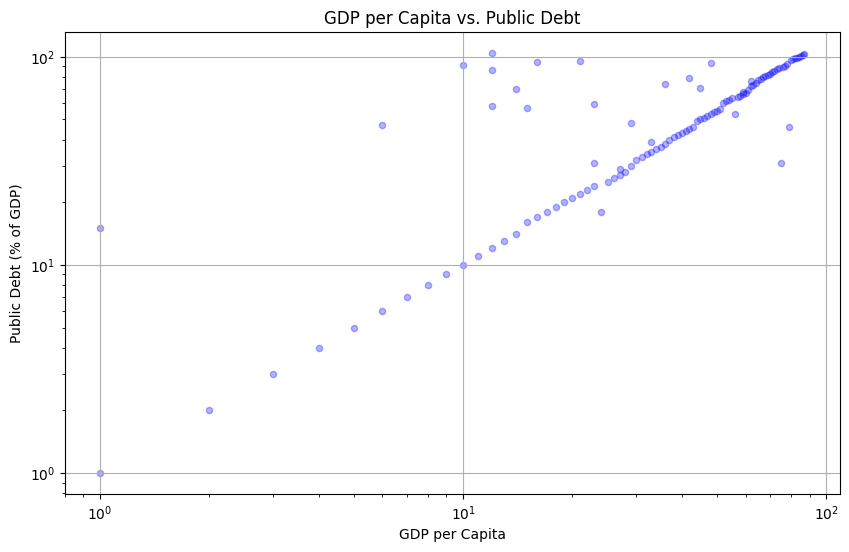

In [ ]:
import matplotlib.pyplot as plt

# Collect the relevant data for plotting
gdp_public_debt = df_cleaned.select("GDP - per capita", "Public debt(% of GDP)").toPandas()

# Drop rows with missing values in the relevant columns
gdp_public_debt = gdp_public_debt.dropna(subset=["GDP - per capita", "Public debt(% of GDP)"])

# Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(gdp_public_debt["GDP - per capita"], gdp_public_debt["Public debt(% of GDP)"], color='blue', alpha=0.3, s=20) #alpha- transparency, s-reduce points
plt.title("GDP per Capita vs. Public Debt")
plt.xlabel("GDP per Capita")
plt.ylabel("Public Debt (% of GDP)")
plt.xscale('log') #Log Scale for Axes
plt.yscale('log') #Log Scale for Axes
plt.grid(True)
plt.show()



---


* Bar Chart of Average GDP per capita and Unemployment Rate by Debt Level

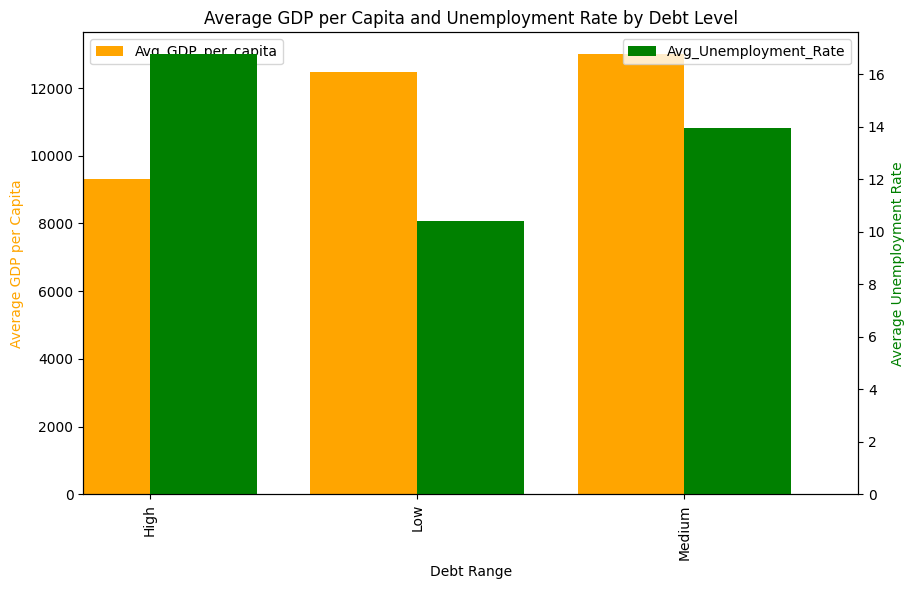

In [ ]:
from pyspark.sql.functions import when, avg

# Add a new Debt_Range column based on Public debt(% of GDP)
df_cleaned = df_cleaned.withColumn(
    "Debt_Range",
    when(df_cleaned["Public debt(% of GDP)"] < 30, "Low")
    .when((df_cleaned["Public debt(% of GDP)"] >= 30) & (df_cleaned["Public debt(% of GDP)"] < 60), "Medium")
    .otherwise("High")
)

# Calculate average GDP per capita and Unemployment Rate by Debt Level
avg_gdp_unemployment_by_debt = df_cleaned.groupBy("Debt_Range").agg(
    avg("`GDP - per capita`").alias("Avg_GDP_per_capita"),
    avg("`Unemployment rate(%)`").alias("Avg_Unemployment_Rate")
).toPandas()

# Bar Chart for Average GDP and Unemployment Rate by Debt Level
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for GDP per capita
avg_gdp_unemployment_by_debt.set_index("Debt_Range")[["Avg_GDP_per_capita"]].plot(kind='bar', ax=ax1, color='orange', position=1, width=0.4)
ax2 = ax1.twinx()

# Bar chart for Unemployment Rate
avg_gdp_unemployment_by_debt.set_index("Debt_Range")[["Avg_Unemployment_Rate"]].plot(kind='bar', ax=ax2, color='green', position=0, width=0.4)

ax1.set_xlabel("Debt Range")
ax1.set_ylabel("Average GDP per Capita", color='orange')
ax2.set_ylabel("Average Unemployment Rate", color='green')

plt.title("Average GDP per Capita and Unemployment Rate by Debt Level")
plt.show()


## **Part 2 - Health and Quality of Life Analysis**
For this analysis, focus is on:

*   Life Expectancy at Birth
*   Infant Mortality Rate
*   Internet Users


---


### **Correlations Between Health Indicators**



In [ ]:
# Ensure columns are of numeric type
from pyspark.sql.functions import col

df = df.withColumn("Life expectancy at birth(years)",col("Life expectancy at birth(years)").cast("double"))
df = df.withColumn("Infant mortality rate(deaths/1000 live births)",col("Infant mortality rate(deaths/1000 live births)").cast("double"))
df = df.withColumn("Internet users",col("Internet users").cast("double"))

# Calculate correlations
print("Correlation between Life Expectancy and Infant Mortality Rate:")
correlation_life_infant = df.stat.corr("Life expectancy at birth(years)", "Infant mortality rate(deaths/1000 live births)")
print(correlation_life_infant)

print("Correlation between Life Expectancy and Internet Users:")
correlation_life_internet = df.stat.corr("Life expectancy at birth(years)", "Internet users")
print(correlation_life_internet)

Correlation between Life Expectancy and Infant Mortality Rate:
-0.02400035756743673
Correlation between Life Expectancy and Internet Users:
0.1370763978356345


The expectation is a strong negative correlation between **life expectancy and infant mortality**, as high life expectancy often accompanies low infant mortality rates. A very weak negative correlation might indicate that in this dataset, other factors play a more significant role in life expectancy and infant mortality independently.

A weak positive correlation between **Life Expectancy and Internet Users**, suggests a slight tendency for countries with more internet users to have higher life expectancy.
However, the correlation is not strong enough to confirm a direct or significant relationship.

### **Grouping by Internet Access Levels**
Grouping countries based on internet access to see if life expectancy varies among them. This will help in observing if countries with more internet access tend to have higher life expectancy on average.

In [ ]:
# Calculate the 20th, 50th, and 80th percentiles (for example)
percentiles = df.approxQuantile("Internet users", [0.2, 0.5, 0.8], 0.0)

# Define ranges for Internet Users based on these percentiles
df = df.withColumn("Internet_Users_Range",
                   when(col("Internet users") < percentiles[0], "Low")
                   .when((col("Internet users") >= percentiles[0]) & (col("Internet users") < percentiles[2]), "Medium")
                   .otherwise("High"))

# Check the result
df.groupBy("Internet_Users_Range").agg(
    avg("Life expectancy at birth(years)").alias("Avg_Life_Expectancy")
).show()


+--------------------+-------------------+
|Internet_Users_Range|Avg_Life_Expectancy|
+--------------------+-------------------+
|                High|  74.52946428571428|
|                 Low|  65.13542857142856|
|              Medium|  65.50328358208954|
+--------------------+-------------------+



* Significantly Higher Life Expectancy for High Internet Users
* Similar Life Expectancy for Low and Medium Internet Users
* Impact of Digital Infrastructure on Public Health

**conclusion 02** - Although high internet usage tend to have significantly higher life expectancy, the similar life expectancy between the low and medium groups suggests that other factors, such as economic conditions, healthcare quality, and social services, are critical in shaping health outcomes alongside internet access.

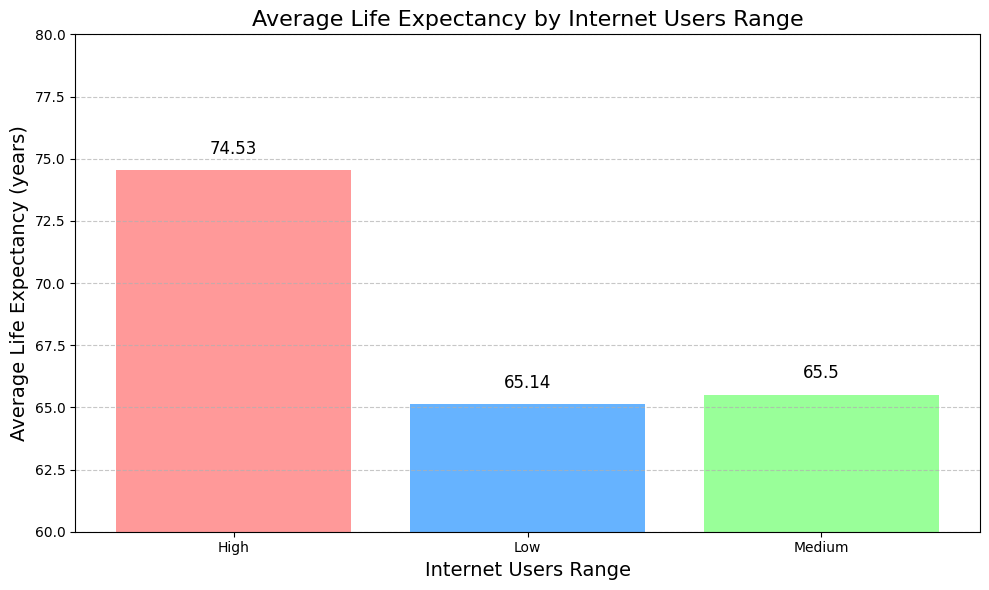

In [ ]:
import matplotlib.pyplot as plt

# Prepare data for plotting
internet_user_ranges = result["Internet_Users_Range"].tolist()
avg_life_expectancy = result["Avg_Life_Expectancy"].tolist()

# Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(internet_user_ranges, avg_life_expectancy, color=['#ff9999', '#66b3ff', '#99ff99'])

# Adding labels and title
plt.xlabel("Internet Users Range", fontsize=14)
plt.ylabel("Average Life Expectancy (years)", fontsize=14)
plt.title("Average Life Expectancy by Internet Users Range", fontsize=16)
plt.ylim(60, 80)

# Annotate bars with their values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, round(yval, 2), ha='center', va='bottom', fontsize=12)

# Display the chart
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **Conclusion**


---
* interconnectedness of economic indicators, internet access, and health outcomes
*  potential benefits of expanding digital infrastructure while also pointing to the complex, multi-dimensional nature of economic and public health challenges
*  valuable for guiding future policies and strategies

Prepared and presented by : D N S D Perera

Date : 08.11.2024

BSc(Honors) in Information Technology

2nd batch
